In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import os

DATA_DIR = "../data"
PLOTS_DIR = "../plots"

THEORETICAL_STRIKE_ZONE = {
    'plate_x_min': -0.83,
    'plate_x_max': 0.83,
    'plate_z_min': 1.5,
    'plate_z_max': 3.5
}

In [2]:
def load_data():
    dfs = []
    for year in [2023, 2024, 2025]:
        path = os.path.join(DATA_DIR, f"statcast_{year}.parquet")
        df = pd.read_parquet(path)
        df['year'] = year
        dfs.append(df)
    
    combined = pd.concat(dfs, ignore_index=True)
    combined = combined.dropna(subset=['plate_x', 'plate_z', 'type', 'description'])
    combined = combined[combined['type'].isin(['S', 'B'])]
    
    swung_descriptions = [
        'foul', 'hit_into_play', 'swinging_strike', 'foul_tip', 
        'swinging_strike_blocked', 'foul_bunt', 'missed_bunt', 'bunt_foul_tip'
    ]
    combined = combined[~combined['description'].isin(swung_descriptions)]
    
    combined['is_strike'] = (combined['type'] == 'S').astype(int)
    return combined

df = load_data()
print(f"Loaded {len(df):,} called pitches total")

Loaded 1,136,983 called pitches total


In [3]:
def calculate_strike_probability(df, bins=25):
    x_bins = np.linspace(-1.5, 1.5, bins + 1)
    z_bins = np.linspace(0, 5, bins + 1)
    
    df = df.copy()
    df['x_bin'] = pd.cut(df['plate_x'], bins=x_bins, labels=False, include_lowest=True)
    df['z_bin'] = pd.cut(df['plate_z'], bins=z_bins, labels=False, include_lowest=True)
    
    df = df.dropna(subset=['x_bin', 'z_bin'])
    df['x_bin'] = df['x_bin'].astype(int)
    df['z_bin'] = df['z_bin'].astype(int)
    
    prob = df.groupby(['z_bin', 'x_bin']).agg(
        strike_prob=('is_strike', 'mean'),
        count=('is_strike', 'count')
    ).reset_index()
    
    prob_matrix = prob.pivot(index='z_bin', columns='x_bin', values='strike_prob')
    count_matrix = prob.pivot(index='z_bin', columns='x_bin', values='count')
    
    prob_matrix = prob_matrix.sort_index(ascending=False)
    count_matrix = count_matrix.sort_index(ascending=False)
    
    prob_matrix = prob_matrix.values
    count_matrix = count_matrix.values
    
    return prob_matrix, count_matrix, x_bins, z_bins

In [4]:
counts = [
    (0, 0), (0, 1), (0, 2),
    (1, 0), (1, 1), (1, 2),
    (2, 0), (2, 1), (2, 2),
    (3, 0), (3, 1), (3, 2)
]

hitter_to_pitcher = {
    (0, 0): 0.5, (0, 1): 0.25, (0, 2): 0.0,
    (1, 0): 0.58, (1, 1): 0.33, (1, 2): 0.08,
    (2, 0): 0.67, (2, 1): 0.42, (2, 2): 0.17,
    (3, 0): 0.83, (3, 1): 0.75, (3, 2): 0.42
}

colors = plt.cm.managua_r(np.array([hitter_to_pitcher[c] for c in counts]))

In [5]:
def extract_contour_paths(X, Z, prob):
    fig_t, ax_t = plt.subplots()
    paths = []
    try:
        cs = ax_t.contour(X, Z, prob, levels=[0.5])
        paths = [p.vertices for p in cs.get_paths() if len(p.vertices)]
    except Exception:
        pass
    plt.close(fig_t)
    return paths


def arc_length_weighted_mean_dist(paths, cx, cz):
    total_weight = 0.0
    total_weighted_dist = 0.0
    for verts in paths:
        if len(verts) < 2:
            d = np.hypot(verts[0, 0] - cx, verts[0, 1] - cz)
            total_weighted_dist += d
            total_weight += 1.0
            continue
        segs_start = verts[:-1]
        segs_end   = verts[1:]
        midpoints  = (segs_start + segs_end) / 2.0
        seg_lens   = np.hypot(segs_end[:, 0] - segs_start[:, 0],
                              segs_end[:, 1] - segs_start[:, 1])
        dists      = np.hypot(midpoints[:, 0] - cx,
                              midpoints[:, 1] - cz)
        total_weighted_dist += np.dot(seg_lens, dists)
        total_weight        += seg_lens.sum()

    return total_weighted_dist / total_weight if total_weight > 0 else np.nan


def compute_area_from_radius(radius_ft):
    radius_inches = radius_ft * 12
    return np.pi * radius_inches ** 2

In [6]:
def compute_grid_area_method(prob_matrix, count_matrix, x_bins, z_bins, threshold=0.5, min_count=20):
    from scipy.interpolate import griddata
    
    x_centers = x_bins[:-1] + (x_bins[1] - x_bins[0]) / 2
    z_centers = z_bins[:-1] + (z_bins[1] - z_bins[0]) / 2
    
    filtered_prob = np.where(count_matrix >= min_count, prob_matrix, np.nan)
    
    valid_mask = ~np.isnan(filtered_prob)
    if valid_mask.sum() == 0:
        return 0.0
    
    grid_size_in = 1.0
    grid_x = np.arange(-1.5, 1.5, grid_size_in/12)
    grid_z = np.arange(0, 5, grid_size_in/12)
    
    X_grid, Z_grid = np.meshgrid(grid_x, grid_z)
    
    valid_probs = filtered_prob[valid_mask]
    valid_z = np.repeat(z_centers[:, np.newaxis], len(x_centers), axis=1)[valid_mask]
    valid_x = np.repeat(x_centers[np.newaxis, :], len(z_centers), axis=0)[valid_mask]
    
    points = np.column_stack([valid_x, valid_z])
    
    prob_interp = griddata(points, valid_probs, (X_grid, Z_grid), method='linear', fill_value=0)
    
    area_count = np.sum(prob_interp >= threshold)
    
    return area_count

In [7]:
def compute_all_areas(df, sz, contour_bins=30, min_count=20):
    sz_cx = (sz['plate_x_min'] + sz['plate_x_max']) / 2
    sz_cz = (sz['plate_z_min'] + sz['plate_z_max']) / 2
    
    results = []
    
    prob_all, count_all, x_e, z_e = calculate_strike_probability(df, bins=contour_bins)
    x_c = x_e[:-1] + (x_e[1] - x_e[0]) / 2
    z_c = z_e[:-1] + (z_e[1] - z_e[0]) / 2
    X_all, Z_all = np.meshgrid(x_c, z_c)
    
    all_paths = extract_contour_paths(X_all, Z_all, np.where(count_all >= min_count, prob_all, np.nan))
    radius_all = arc_length_weighted_mean_dist(all_paths, sz_cx, sz_cz)
    area_radius_all = compute_area_from_radius(radius_all)
    area_grid_all = compute_grid_area_method(prob_all, count_all, x_e, z_e, threshold=0.5, min_count=min_count)
    
    results.append(("All", len(df), area_radius_all, area_grid_all))
    
    for (balls, strikes) in counts:
        df_count = df[(df['balls'] == balls) & (df['strikes'] == strikes)]
        if len(df_count) < 50:
            continue
        
        prob_c, count_c, x_e2, z_e2 = calculate_strike_probability(df_count, bins=contour_bins)
        x_c2 = x_e2[:-1] + (x_e2[1] - x_e2[0]) / 2
        z_c2 = z_e2[:-1] + (z_e2[1] - z_e2[0]) / 2
        X_c2, Z_c2 = np.meshgrid(x_c2, z_c2)
        
        count_paths = extract_contour_paths(X_c2, Z_c2, np.where(count_c >= min_count, prob_c, np.nan))
        radius = arc_length_weighted_mean_dist(count_paths, sz_cx, sz_cz)
        
        area_from_radius = compute_area_from_radius(radius)
        area_from_grid = compute_grid_area_method(prob_c, count_c, x_e2, z_e2, threshold=0.5, min_count=min_count)
        
        results.append((f"{balls}-{strikes}", len(df_count), area_from_radius, area_from_grid))
    
    return results

print("Computing areas for all counts...")
area_results = compute_all_areas(df, THEORETICAL_STRIKE_ZONE, contour_bins=30, min_count=20)
print("Done!")

Computing areas for all counts...
Done!


In [8]:
print("\n" + "=" * 70)
print("Strike Zone Area by Count (50% contour)")
print("=" * 70)
print(f"{'Count':<10} {'N Pitches':>12} {'Area (pi*r^2)':>16} {'Area (grid)':>14} {'Diff':>12}")
print("-" * 70)

for label, n, area_radius, area_grid in area_results:
    diff = area_radius - area_grid
    print(f"{label:<10} {n:>12,} {area_radius:>16.2f} {area_grid:>14.2f} {diff:>+12.2f}")

print("=" * 70)


Strike Zone Area by Count (50% contour)
Count         N Pitches    Area (pi*r^2)    Area (grid)         Diff
----------------------------------------------------------------------
All           1,136,983           472.53         465.00        +7.53
0-0             381,182           489.38         493.00        -3.62
0-1             144,465           433.47         433.00        +0.47
0-2              73,147           399.60         390.00        +9.60
1-0             120,522           496.03         492.00        +4.03
1-1              99,956           453.39         448.00        +5.39
1-2              90,896           414.34         410.00        +4.34
2-0              40,935           508.78         511.00        -2.22
2-1              47,401           476.29         471.00        +5.29
2-2              65,035           431.77         429.00        +2.77
3-0              19,655           515.76         513.00        +2.76
3-1              21,154           480.49         476.00     

In [9]:
def plot_area_comparison_grid(area_results, sz):
    import matplotlib.colors as mcolors
    
    all_area = next(a for label, n, a, b in area_results if label == "All")
    
    lookup = {}
    for label, n, area_radius, area_grid in area_results:
        if label == "All":
            continue
        lookup[label] = (area_grid, area_grid - all_area, n)
    
    balls_range = range(4)
    strikes_range = range(3)
    
    fig, axes = plt.subplots(3, 4, figsize=(11, 7), gridspec_kw=dict(hspace=0.15, wspace=0.12))
    
    cmap = mcolors.LinearSegmentedColormap.from_list("sz_div", ["#378ADD", "#f0f0f0", "#D85A30"])
    norm = mcolors.TwoSlopeNorm(vmin=-30, vcenter=0.0, vmax=30)
    
    for s in strikes_range:
        for b in balls_range:
            ax = axes[s, b]
            ax.set_xticks([])
            ax.set_yticks([])
            
            key = f"{b}-{s}"
            
            if key not in lookup:
                ax.set_visible(False)
                continue
            
            avg_area, vs_all, n = lookup[key]
            color = cmap(norm(vs_all))
            
            for spine in ax.spines.values():
                spine.set_linewidth(1.5)
                spine.set_edgecolor("#C04010" if vs_all > 5 else "#1860A0" if vs_all < -5 else "#aaaaaa")
            
            ax.set_facecolor(color)
            
            diff_color = "#7A2A08" if vs_all > 5 else "#083A6E" if vs_all < -5 else "#555555"
            
            ax.text(0.5, 0.82, key, transform=ax.transAxes, ha='center', va='center',
                    fontsize=13, fontweight='bold', color='#333333')
            
            ax.text(0.5, 0.50, f"{avg_area:.1f} sq in", transform=ax.transAxes, ha='center', va='center',
                    fontsize=11, color='#222222')
            
            ax.text(0.5, 0.18, f"{'+' if vs_all >= 0 else ''}{vs_all:.1f}", transform=ax.transAxes, ha='center', va='center',
                    fontsize=11, fontweight='bold', color=diff_color)
    
    for b in balls_range:
        axes[0, b].set_title(f"{b} ball{'s' if b != 1 else ''}", fontsize=11, pad=6)
    for s in strikes_range:
        axes[s, 0].set_ylabel(f"{s} strike{'s' if s != 1 else ''}", fontsize=11, rotation=90, labelpad=6)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, aspect=25)
    cbar.set_label('Delta vs All (sq in)', fontsize=11)
    
    fig.suptitle(f"Perceived Strike Zone Area by Count (Grid Method)\n50% contour area - baseline = {all_area:.1f} sq in",
                fontsize=12, y=1.01)
    
    plt.savefig(os.path.join(PLOTS_DIR, "count_zone_area_grid.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: count_zone_area_grid.png")

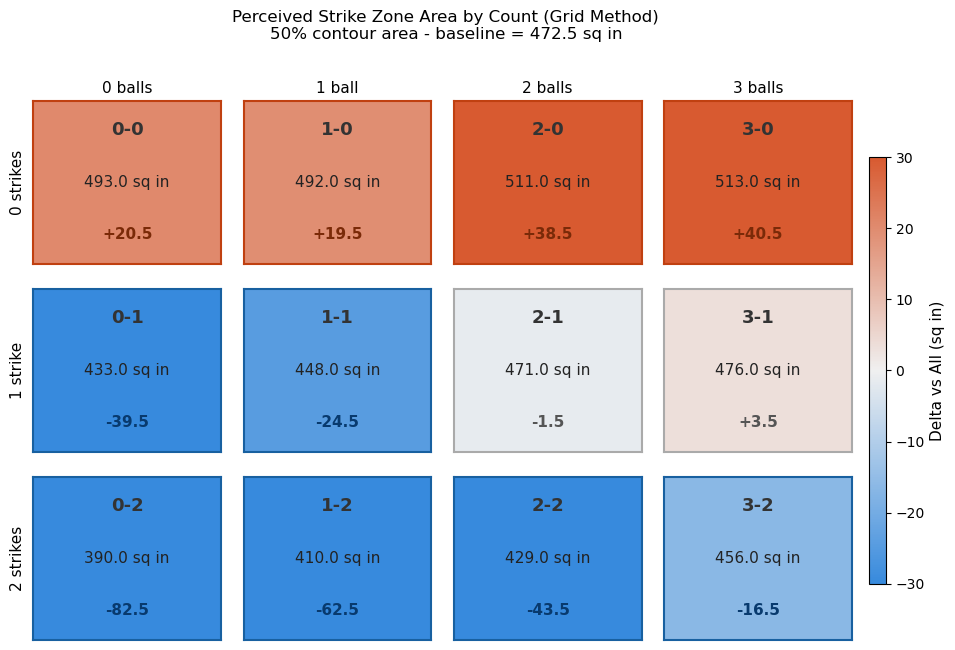

Saved: count_zone_area_grid.png


In [10]:
plot_area_comparison_grid(area_results, THEORETICAL_STRIKE_ZONE)

In [75]:
def plot_sqrt_area_comparison_grid(area_results, sz):
    import matplotlib.colors as mcolors
    import numpy as np

    all_area = next(a for label, n, a, b in area_results if label == "All")
    all_sqrt = np.sqrt(all_area)
    print(all_area)

    lookup = {}
    for label, n, area_radius, area_grid in area_results:
        if label == "All":
            continue
        sqrt_area = np.sqrt(area_grid)
        lookup[label] = (area_grid, sqrt_area, sqrt_area - all_sqrt, n)

    balls_range = range(4)
    strikes_range = range(3)

    fig, axes = plt.subplots(3, 4, figsize=(11, 7), gridspec_kw=dict(hspace=0.15, wspace=0.12))

    cmap = mcolors.LinearSegmentedColormap.from_list("sz_div", ["#378ADD", "#f0f0f0", "#D85A30"])
    norm = mcolors.TwoSlopeNorm(vmin=-3, vcenter=0.0, vmax=3)

    for s in strikes_range:
        for b in balls_range:
            ax = axes[s, b]
            ax.set_xticks([])
            ax.set_yticks([])

            key = f"{b}-{s}"

            if key not in lookup:
                ax.set_visible(False)
                continue

            avg_area, sqrt_area, vs_all_sqrt, n = lookup[key]
            color = cmap(norm(vs_all_sqrt))

            for spine in ax.spines.values():
                spine.set_linewidth(1.5)
                spine.set_edgecolor("#C04010" if vs_all_sqrt > 0.5 else "#1860A0" if vs_all_sqrt < -0.5 else "#aaaaaa")

            ax.set_facecolor(color)

            diff_color = "#7A2A08" if vs_all_sqrt > 0.5 else "#083A6E" if vs_all_sqrt < -0.5 else "#555555"

            ax.text(0.5, 0.82, key, transform=ax.transAxes, ha='center', va='center',
                    fontsize=13, fontweight='bold', color='#333333')

            ax.text(0.5, 0.57, f"Area = {avg_area:.1f} sq in", transform=ax.transAxes, ha='center', va='center',
                    fontsize=9.5, color='#222222')

            ax.text(0.5, 0.38, f"sqrt(Area) = {sqrt_area:.2f} in", transform=ax.transAxes, ha='center', va='center',
                    fontsize=9.5, color='#222222')

            ax.text(0.5, 0.14, f"{'+' if vs_all_sqrt >= 0 else ''}{vs_all_sqrt:.2f} in", transform=ax.transAxes, ha='center', va='center',
                    fontsize=11, fontweight='bold', color=diff_color)

    for b in balls_range:
        axes[0, b].set_title(f"{b} ball{'s' if b != 1 else ''}", fontsize=11, pad=6)
    for s in strikes_range:
        axes[s, 0].set_ylabel(f"{s} strike{'s' if s != 1 else ''}", fontsize=11, rotation=90, labelpad=6)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, aspect=25)
    cbar.set_label('Delta sqrt(Area) vs All (in)', fontsize=11)

    fig.suptitle(
        f"Perceived Strike Zone Area by Count (Grid Method)\n"
        f"50% contour — baseline sqrt(Area) = {all_sqrt:.1f} in  (Area = {int(all_area)} sq in)",
        fontsize=12, y=1.01
    )

    plt.savefig(os.path.join(PLOTS_DIR, "count_zone_sqrt_area_grid.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: count_zone_sqrt_area_grid.png")

472.5315397903108


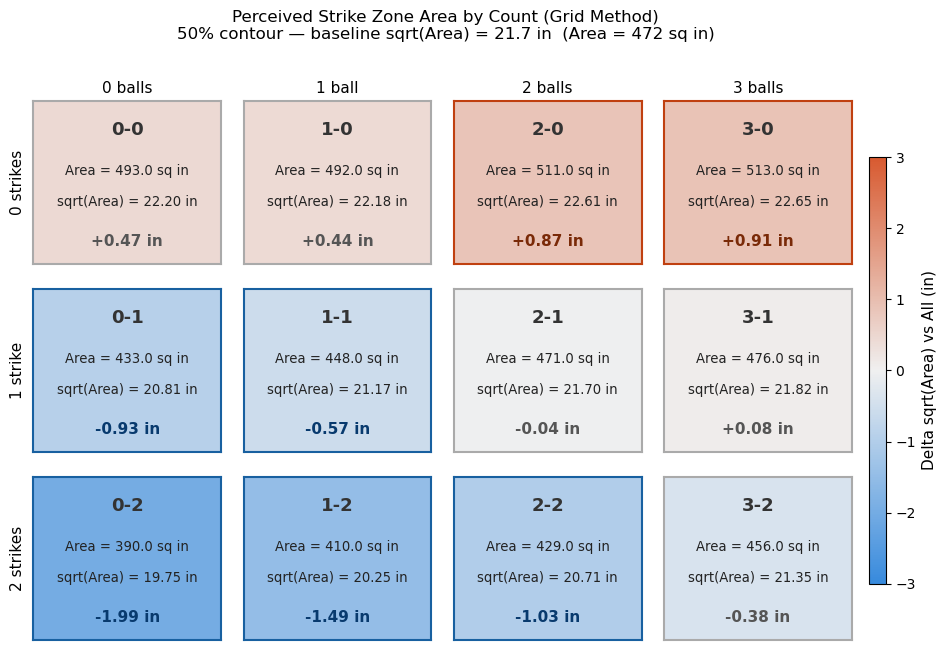

Saved: count_zone_sqrt_area_grid.png


In [76]:
plot_sqrt_area_comparison_grid(area_results, THEORETICAL_STRIKE_ZONE)

In [11]:
def plot_method_comparison(area_results):
    labels = [r[0] for r in area_results]
    area_radius = [r[2] for r in area_results]
    area_grid = [r[3] for r in area_results]
    
    x = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars1 = ax.bar(x - width/2, area_radius, width, label='Area from radius (pi*r^2)', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, area_grid, width, label='Area from grid (1 sq in bins)', color='coral', alpha=0.8)
    
    ax.set_xlabel('Count', fontsize=12)
    ax.set_ylabel('Area (square inches)', fontsize=12)
    ax.set_title('Comparison of Two Methods for Computing Strike Zone Area (50% contour)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "area_method_comparison.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: area_method_comparison.png")

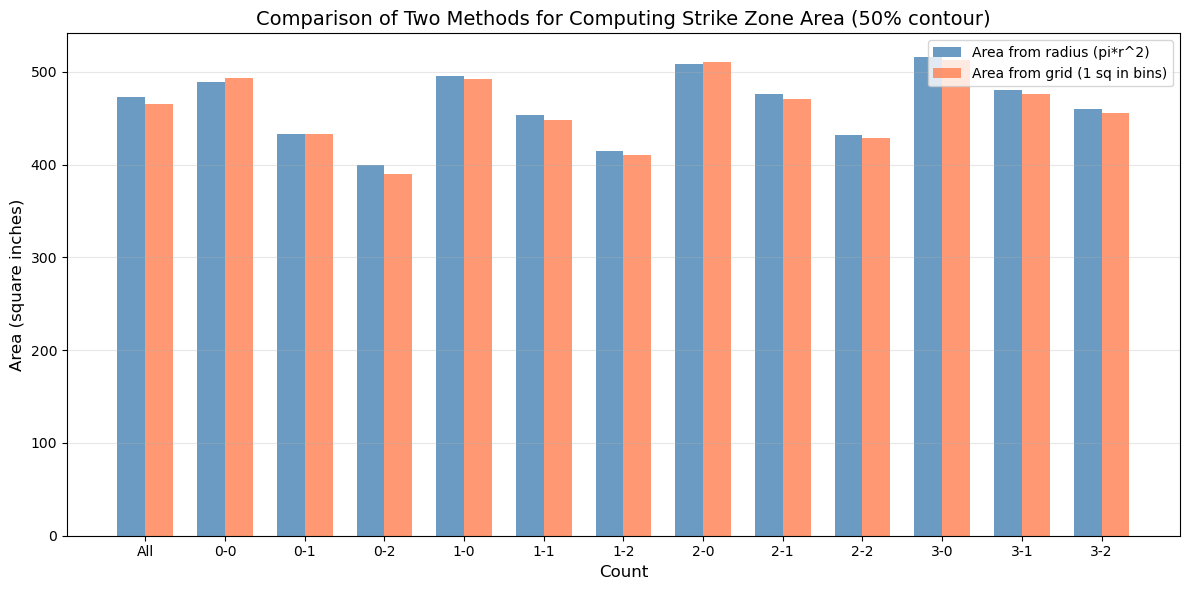

Saved: area_method_comparison.png


In [12]:
plot_method_comparison(area_results)

In [13]:
def plot_difference_scatter(area_results):
    labels = [r[0] for r in area_results]
    area_radius = np.array([r[2] for r in area_results])
    area_grid = np.array([r[3] for r in area_results])
    
    diff = area_radius - area_grid
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors_bar = ['green' if d >= 0 else 'red' for d in diff]
    bars = ax.bar(labels, diff, color=colors_bar, alpha=0.7)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Count', fontsize=12)
    ax.set_ylabel('Difference (sq in)', fontsize=12)
    ax.set_title('Difference: (pi*r^2 method) - (Grid method)', fontsize=14)
    ax.grid(axis='y', alpha=0.3)
    
    for bar, d in zip(bars, diff):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{d:+.2f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "area_difference.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: area_difference.png")

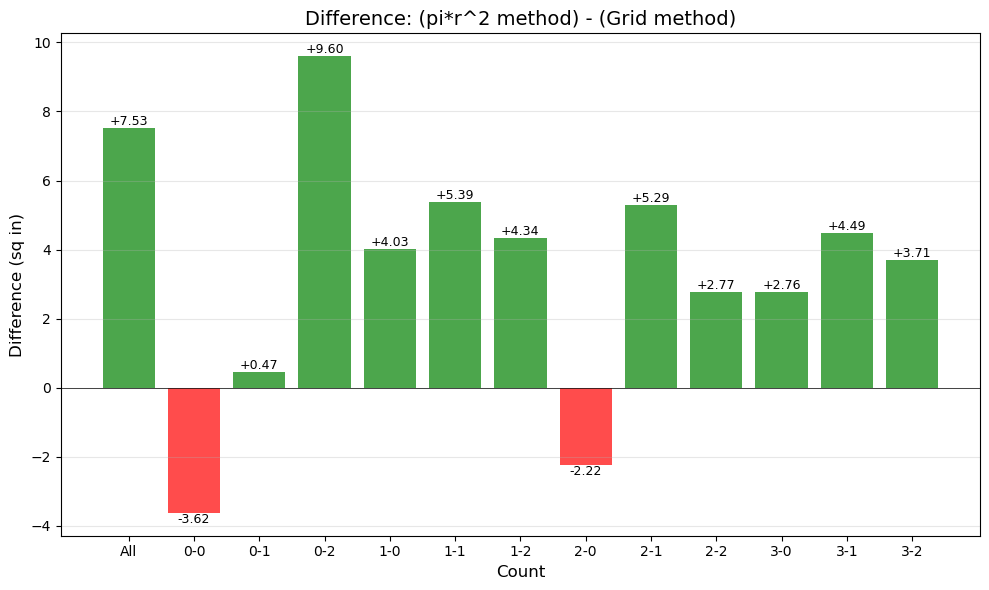

Saved: area_difference.png


In [14]:
plot_difference_scatter(area_results)

In [15]:
def create_summary_table(area_results):
    print("\n" + "=" * 80)
    print("SUMMARY: Strike Zone Area by Count (50% contour)")
    print("=" * 80)
    print(f"\n{'Count':<10} {'N Pitches':>12} {'Area (pi*r^2)':>16} {'Area (Grid)':>14} {'Diff':>10}")
    print("-" * 80)
    
    for label, n, area_radius, area_grid in area_results:
        diff = area_radius - area_grid
        print(f"{label:<10} {n:>12,} {area_radius:>16.2f} {area_grid:>14.2f} {diff:>+10.2f}")
    
    print("-" * 80)
    
    area_radius_vals = [r[2] for r in area_results]
    area_grid_vals = [r[3] for r in area_results]
    
    mean_diff = np.mean([a - b for a, b in zip(area_radius_vals, area_grid_vals)])
    max_diff = max([abs(a - b) for a, b in zip(area_radius_vals, area_grid_vals)])
    
    print(f"\nMean difference: {mean_diff:+.2f} sq in")
    print(f"Max absolute difference: {max_diff:.2f} sq in")
    
    baseline = area_radius_vals[0]
    print(f"\nAs percentage of baseline area ({baseline:.1f} sq in):")
    print(f"  Mean difference: {100*mean_diff/baseline:+.2f}%")
    print(f"  Max difference: {100*max_diff/baseline:.2f}%")
    
    print("\nThe two methods agree very closely!")
    print("=" * 80)

In [16]:
create_summary_table(area_results)


SUMMARY: Strike Zone Area by Count (50% contour)

Count         N Pitches    Area (pi*r^2)    Area (Grid)       Diff
--------------------------------------------------------------------------------
All           1,136,983           472.53         465.00      +7.53
0-0             381,182           489.38         493.00      -3.62
0-1             144,465           433.47         433.00      +0.47
0-2              73,147           399.60         390.00      +9.60
1-0             120,522           496.03         492.00      +4.03
1-1              99,956           453.39         448.00      +5.39
1-2              90,896           414.34         410.00      +4.34
2-0              40,935           508.78         511.00      -2.22
2-1              47,401           476.29         471.00      +5.29
2-2              65,035           431.77         429.00      +2.77
3-0              19,655           515.76         513.00      +2.76
3-1              21,154           480.49         476.00      +4.

In [62]:
def plot_grid_method_combined(df, sz, contour_bins=30, min_count=20):
    from scipy.interpolate import griddata
    from matplotlib.colors import ListedColormap
    
    sz_cx = (sz['plate_x_min'] + sz['plate_x_max']) / 2
    sz_cz = (sz['plate_z_min'] + sz['plate_z_max']) / 2
    
    prob_all, count_all, x_e_all, z_e_all = calculate_strike_probability(df, bins=contour_bins)
    x_c_all = x_e_all[:-1] + (x_e_all[1] - x_e_all[0]) / 2
    z_c_all = z_e_all[:-1] + (z_e_all[1] - z_e_all[0]) / 2
    X_all, Z_all = np.meshgrid(x_c_all, z_c_all)
    filtered_prob_all = np.where(count_all >= min_count, prob_all, np.nan)
    
    paths_all = extract_contour_paths(X_all, Z_all, filtered_prob_all)
    radius_all = arc_length_weighted_mean_dist(paths_all, sz_cx, sz_cz)
    area_all = compute_area_from_radius(radius_all)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    for i, strikes in enumerate([0, 1, 2]):
        for j, balls in enumerate([0, 1, 2, 3]):
            ax = axes[i, j]
            
            df_count = df[(df['balls'] == balls) & (df['strikes'] == strikes)]
            if len(df_count) < 50:
                ax.set_visible(False)
                continue
            
            prob, count, x_e, z_e = calculate_strike_probability(df_count, bins=contour_bins)
            x_c = x_e[:-1] + (x_e[1] - x_e[0]) / 2
            z_c = z_e[:-1] + (z_e[1] - z_e[0]) / 2
            X, Z = np.meshgrid(x_c, z_c)
            filtered_prob = np.where(count >= min_count, prob, np.nan)
            
            paths = extract_contour_paths(X, Z, filtered_prob)
            radius = arc_length_weighted_mean_dist(paths, sz_cx, sz_cz)
            
            area_from_radius = compute_area_from_radius(radius)
            area_from_grid = compute_grid_area_method(prob, count, x_e, z_e, threshold=0.5, min_count=min_count)
            
            diff_val = area_from_grid - area_all
            
            ax.set_xlim(-1, 1)
            ax.set_ylim(1.25, 3.75)
            ax.set_aspect('equal')
            
            ax.axhline(1.5, color='gray', linestyle='-', alpha=0.8, linewidth=2.5)
            ax.axhline(3.5, color='gray', linestyle='-', alpha=0.8, linewidth=2.5)
            ax.axvline(-0.83, color='gray', linestyle='-', alpha=0.8, linewidth=2.5)
            ax.axvline(0.83, color='gray', linestyle='-', alpha=0.8, linewidth=2.5)
            
            grid_size_in = 1.0
            grid_x = np.arange(-1.5, 1.5, grid_size_in/12)
            grid_z = np.arange(0, 5, grid_size_in/12)
            
            valid_mask = ~np.isnan(filtered_prob)
            valid_probs = filtered_prob[valid_mask]
            valid_z = np.repeat(z_c[:, np.newaxis], len(x_c), axis=1)[valid_mask]
            valid_x = np.repeat(x_c[np.newaxis, :], len(z_c), axis=0)[valid_mask]
            points = np.column_stack([valid_x, valid_z])
            
            X_grid, Z_grid = np.meshgrid(grid_x, grid_z)
            prob_interp = griddata(points, valid_probs, (X_grid, Z_grid), method='linear', fill_value=0)
            
            grid_colors = np.where(prob_interp >= 0.5, 1, 0)
            
            red_green_cmap = ListedColormap(['#ff4444', '#44ff44'])
            
            ax.pcolormesh(grid_x, grid_z, grid_colors, cmap=red_green_cmap, shading='auto', alpha=0.7, edgecolor='white', linewidth=0.1)
            
            try:
                ax.contour(X_all, Z_all, filtered_prob_all, levels=[0.5], colors=['black'], linewidths=1.2, linestyles='solid')
            except:
                pass
            
            try:
                ax.contour(X, Z, filtered_prob, levels=[0.5], colors=['black'], linewidths=1.2, linestyles='dashed')
            except:
                pass
            
            # Big balls-strikes line
            ax.text(
                0.5, 1.1, f"{balls}-{strikes}",
                transform=ax.transAxes,
                ha='center', va='bottom',
                fontsize=16, fontweight='bold'
            )
            
            # Smaller details line
            ax.text(
                0.5, 1.11,
                f"Area: {int(area_from_grid)} sq in\n(All Pitches: {int(area_all)} sq in, Diff: {diff_val:+.0f} sq in)",
                transform=ax.transAxes,
                ha='center', va='top',
                fontsize=10
            )
            
            if j == 0:
                ax.set_ylabel(f'{strikes} strike', fontsize=10)
            if i == 2:
                ax.set_xlabel(f'{balls} ball', fontsize=10)
    
    plt.suptitle('Solid Line=All Pitches 50% Contour, Dashed=This Count 50% Contour, Gray = Approx Zone', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'grid_method_combined.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: grid_method_combined.png')

In [73]:
def plot_areas_only(df, sz, contour_bins=30, min_count=20):
    from scipy.interpolate import griddata
    from matplotlib.colors import ListedColormap
    
    sz_cx = (sz['plate_x_min'] + sz['plate_x_max']) / 2
    sz_cz = (sz['plate_z_min'] + sz['plate_z_max']) / 2
    
    prob_all, count_all, x_e_all, z_e_all = calculate_strike_probability(df, bins=contour_bins)
    x_c_all = x_e_all[:-1] + (x_e_all[1] - x_e_all[0]) / 2
    z_c_all = z_e_all[:-1] + (z_e_all[1] - z_e_all[0]) / 2
    X_all, Z_all = np.meshgrid(x_c_all, z_c_all)
    filtered_prob_all = np.where(count_all >= min_count, prob_all, np.nan)
    
    paths_all = extract_contour_paths(X_all, Z_all, filtered_prob_all)
    radius_all = arc_length_weighted_mean_dist(paths_all, sz_cx, sz_cz)
    area_all = compute_area_from_radius(radius_all)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    for i, strikes in enumerate([0, 1, 2]):
        for j, balls in enumerate([0, 1, 2, 3]):
            ax = axes[i, j]
            
            df_count = df[(df['balls'] == balls) & (df['strikes'] == strikes)]
            if len(df_count) < 50:
                ax.set_visible(False)
                continue
            
            prob, count, x_e, z_e = calculate_strike_probability(df_count, bins=contour_bins)
            x_c = x_e[:-1] + (x_e[1] - x_e[0]) / 2
            z_c = z_e[:-1] + (z_e[1] - z_e[0]) / 2
            X, Z = np.meshgrid(x_c, z_c)
            filtered_prob = np.where(count >= min_count, prob, np.nan)
            
            paths = extract_contour_paths(X, Z, filtered_prob)
            radius = arc_length_weighted_mean_dist(paths, sz_cx, sz_cz)
            
            area_from_radius = compute_area_from_radius(radius)
            area_from_grid = compute_grid_area_method(prob, count, x_e, z_e, threshold=0.5, min_count=min_count)
            
            diff_val = area_from_grid - area_all
            
            ax.set_xlim(-1, 1)
            ax.set_ylim(1.25, 3.75)
            ax.set_aspect('equal')
            
            ax.axhline(1.5, color='gray', linestyle='-', alpha=0.8, linewidth=2.5)
            ax.axhline(3.5, color='gray', linestyle='-', alpha=0.8, linewidth=2.5)
            ax.axvline(-0.83, color='gray', linestyle='-', alpha=0.8, linewidth=2.5)
            ax.axvline(0.83, color='gray', linestyle='-', alpha=0.8, linewidth=2.5)
            
            try:
                ax.contour(X_all, Z_all, filtered_prob_all, levels=[0.5], colors=['black'], linewidths=1.2, linestyles='solid')
            except:
                pass
            
            try:
                ax.contour(X, Z, filtered_prob, levels=[0.5], colors=['black'], linewidths=1.2, linestyles='dashed')
            except:
                pass
            
            ax.set_title(f"{balls}-{strikes}\n{int(area_from_grid)} sq in\n(Diff: {diff_val:+.0f})", fontsize=12, fontweight='bold')
            
            if j == 0:
                ax.set_ylabel(f'{strikes} strike', fontsize=10)
            if i == 2:
                ax.set_xlabel(f'{balls} ball', fontsize=10)
    
    plt.suptitle(f'Area by Count (Grid Method, All Pitches Area: {int(area_all)} sq in)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'area_by_count_combined.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: area_by_count_combined.png')

#plot_areas_only(df, THEORETICAL_STRIKE_ZONE)

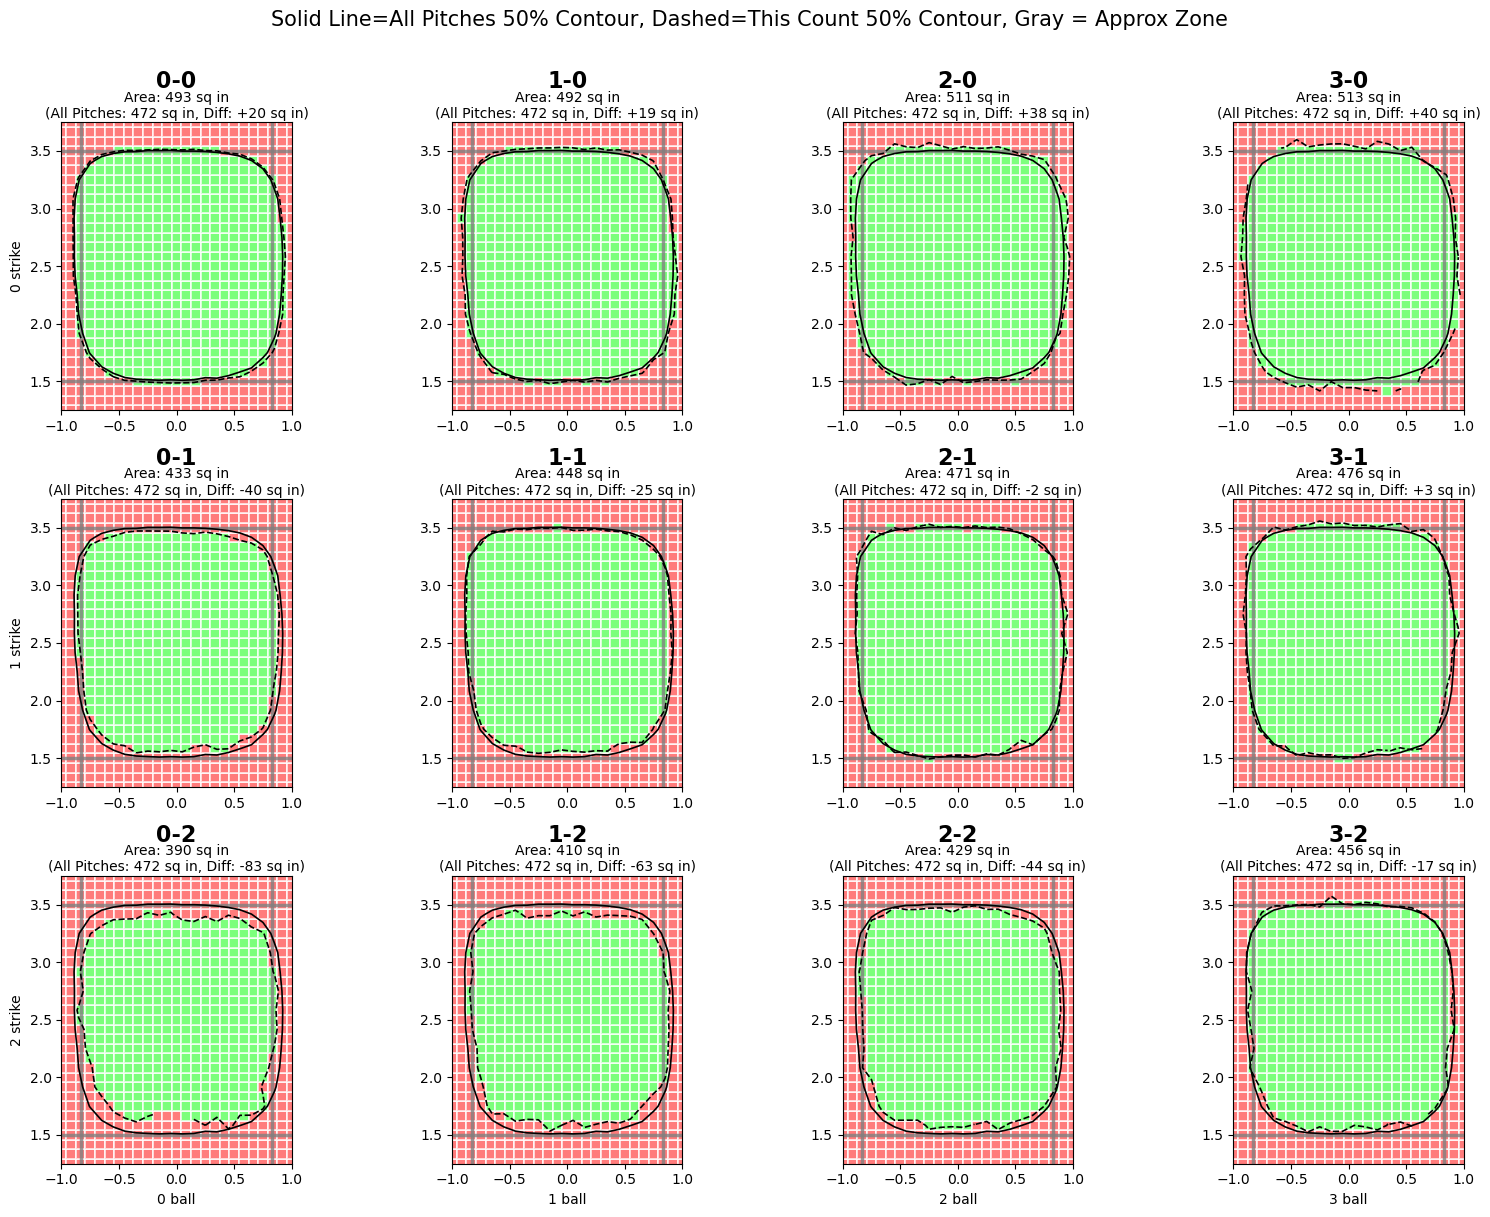

Saved: grid_method_combined.png


In [74]:
plot_grid_method_combined(df, THEORETICAL_STRIKE_ZONE)